In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from adjustText import adjust_text
import seaborn as sns
from matplotlib import rcParams


# --- Setup Matplotlib for consistent font rendering ---
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

In [ ]:
Daporinad_pathway = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Fig_7n.csv")

In [3]:
Daporinad_pathway

,Term,Library,p-value,q-value,z-score,combined score,overlaps
0,Extracellular Matrix Organization R-HSA-1474244,Reactome_2022,3.102000e-31,4.293000e-28,4.793,336.70,COL16A1;COL12A1;SERPINE1;ICAM2;ICAM3;PLOD2;LOX...
1,extracellular matrix organization (GO:0030198),GO_Biological_Process_2021,3.203000e-29,1.482000e-25,4.496,295.00,APP;COL16A1;COL12A1;SERPINE1;ICAM2;TNC;ICAM3;P...
2,extracellular structure organization (GO:0043062),GO_Biological_Process_2021,1.552000e-26,3.524000e-23,5.176,307.60,DDR1;APP;COL18A1;COL16A1;ITGAM;ITGB5;ITGB4;SER...
3,external encapsulating structure organization ...,GO_Biological_Process_2021,2.284000e-26,3.524000e-23,5.136,303.20,DDR1;APP;COL18A1;COL16A1;ITGAM;ITGB5;ITGB4;SER...
4,nervous system development (GO:0007399),GO_Biological_Process_2021,4.457000e-20,5.156000e-17,2.952,131.50,SEMA5A;NCKAP1;CHRM3;GDA;MSI1;CELSR1;CDH2;OPHN1...
5,regulation of cell migration (GO:0030334),GO_Biological_Process_2021,9.800000e-19,9.071000e-16,2.967,123.00,SEMA5A;CSF1;SERPINE1;LDLRAD4;FGF1;CLDN1;CXCL16...
6,Non-integrin membrane-ECM Interactions R-HSA-3...,Reactome_2022,1.343000e-18,9.295000e-16,18.560,763.90,DDR1;LAMA5;ITGB5;LAMA2;SDC4;ITGB4;LAMA1;LAMA4;...
7,RHO GTPase Cycle R-HSA-9012999,Reactome_2022,8.310000e-18,3.834000e-15,2.799,110.10,CYFIP2;NCKAP1;STEAP3;TRIO;RTKN;WIPF1;NCF2;ARHG...
8,RAC1 GTPase Cycle R-HSA-9013149,Reactome_2022,1.973000e-17,6.827000e-15,4.354,167.50,CYFIP2;ARHGAP9;NCKAP1;DOCK5;DOCK4;TRIO;NCF2;WI...
9,ECM-receptor interaction,KEGG_2021_Human,3.016000e-16,8.806000e-14,6.723,240.30,LAMA5;ITGB5;LAMA2;SDC4;ITGB4;LAMA1;LAMA4;LAMA3...


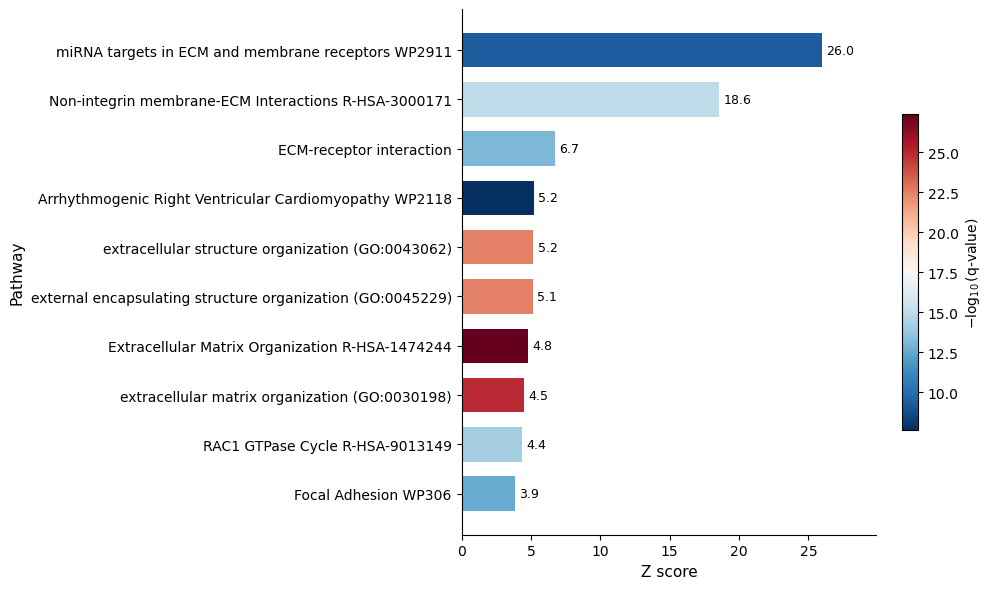

In [6]:
# Select top pathways and prepare data
# Sort by z-score and select top 10
top_pathways = Daporinad_pathway.nlargest(10, 'z-score').copy()

# Calculate -log10(q-value)
top_pathways['-log10_qvalue'] = -np.log10(top_pathways['q-value'])

# Sort by z-score for plotting (ascending so highest appears at top)
top_pathways = top_pathways.sort_values('z-score', ascending=True)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create colormap normalization
norm = plt.Normalize(vmin=top_pathways['-log10_qvalue'].min(), 
                     vmax=top_pathways['-log10_qvalue'].max())
#norm = plt.Normalize(vmin=0, vmax=1.2)  # example fixed scale


cmap = plt.cm.RdBu_r  # Red-Blue reversed (blue=low, red=high)

# Get colors for each bar based on -log10(q-value)
colors = cmap(norm(top_pathways['-log10_qvalue'].values))

# Create horizontal bar plot
bars = ax.barh(y=range(len(top_pathways)), 
               width=top_pathways['z-score'].values,
               color=colors,
               edgecolor='none',
               height=0.7)

# Set y-tick labels (pathway names)
# Clean up pathway names by removing extra info in parentheses if too long
pathway_labels = top_pathways['Term'].values
ax.set_yticks(range(len(top_pathways)))
ax.set_yticklabels(pathway_labels, fontsize=10)

# Add value labels at the end of each bar
for i, (bar, val) in enumerate(zip(bars, top_pathways['z-score'].values)):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}', va='center', ha='left', fontsize=9)

# Set labels
ax.set_xlabel('Z score', fontsize=11)
ax.set_ylabel('Pathway', fontsize=11)

# Set x-axis limits to accommodate labels
ax.set_xlim(0, top_pathways['z-score'].max() * 1.15)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, aspect=20)
cbar.set_label(r'$-\log_{10}$(q-value)', fontsize=10)

plt.tight_layout()
plt.savefig('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code/Daporinad_pathway_barplot.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()